In [7]:
import numpy as np

N = 100  # number of samples
X = np.random.normal(loc=3, scale=2, size=(N, 2))  # X=X[:,0] (first feature), Y=X[:,1] (second feature)
W = np.random.normal(size=N)
Z = X[:, 0] + 0.5 * X[:, 1] + 0.1 * W

# split the data into training and testing sets
from sklearn.model_selection import train_test_split
train_X, test_X, train_Z, test_Z = train_test_split(X, Z, test_size=0.25)

from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(n_estimators=20)  # RF with 20 trees
rf.fit(train_X, train_Z)

Zp = rf.predict(test_X)
Zt = rf.predict(train_X)

from sklearn.metrics import mean_squared_error as mse, r2_score as rsq

print("RF Training R2: %3.1f, MSE: %3.3f" % (rsq(train_Z, Zt), mse(train_Z, Zt)))
print("RF Testing R2: %3.1f, MSE: %3.3f" % (rsq(test_Z, Zp), mse(test_Z, Zp)))


RF Training R2: 1.0, MSE: 0.107
RF Testing R2: 1.0, MSE: 0.154


Intercept = 1.2365509743324412 Slope = [1.04142664]
LR(X) Training R2: 0.8, MSE: 1.156
LR(X) Testing R2: 0.8, MSE: 0.975


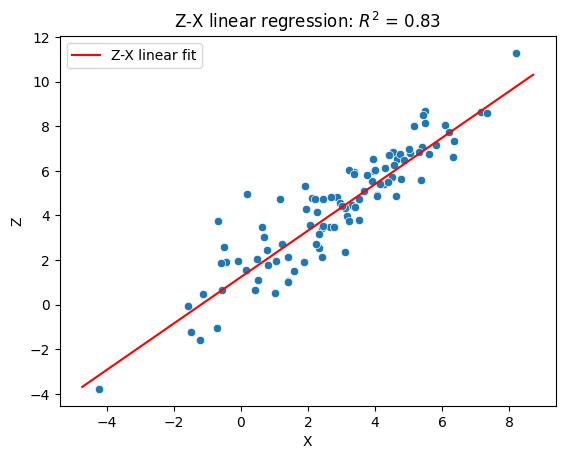

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import linear_model

# Fit linear regression using only X[:,0]
regr = linear_model.LinearRegression()
regr.fit(train_X[:, 0:1], train_Z)

Zp = regr.predict(test_X[:, 0:1])
Zt = regr.predict(train_X[:, 0:1])

# Draw the fit line
x = np.linspace(np.min(X[:, 0]) - 0.5, np.max(X[:, 0]) + 0.5, 1000)
z = regr.predict(x[:, np.newaxis])

ax = sns.scatterplot(x=X[:, 0], y=Z)
ax.plot(x, z, 'r-', label='Z-X linear fit')

plt.xlabel('X')
plt.ylabel('Z')
plt.legend()

print('Intercept =', regr.intercept_, 'Slope =', regr.coef_)
plt.title("Z-X linear regression: $R^2$ = %3.2f" % (regr.score(train_X[:, 0:1], train_Z)))

print("LR(X) Training R2: %3.1f, MSE: %3.3f" % (rsq(train_Z, Zt), mse(train_Z, Zt)))
print("LR(X) Testing R2: %3.1f, MSE: %3.3f" % (rsq(test_Z, Zp), mse(test_Z, Zp)))


# Predict next-day rain in Australia

In [17]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

df = pd.read_csv("weatherAUS.csv")

df

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145455,2017-06-21,Uluru,2.8,23.4,0.0,NaN,NaN,E,31.0,SE,...,51.0,24.0,1024.6,1020.3,NaN,NaN,10.1,22.4,No,No
145456,2017-06-22,Uluru,3.6,25.3,0.0,NaN,NaN,NNW,22.0,SE,...,56.0,21.0,1023.5,1019.1,NaN,NaN,10.9,24.5,No,No
145457,2017-06-23,Uluru,5.4,26.9,0.0,NaN,NaN,N,37.0,SE,...,53.0,24.0,1021.0,1016.8,NaN,NaN,12.5,26.1,No,No
145458,2017-06-24,Uluru,7.8,27.0,0.0,NaN,NaN,SE,28.0,SSE,...,51.0,24.0,1019.4,1016.5,3.0,2.0,15.1,26.0,No,No


Note, that the variable **RainTomorrow**, which will be our outcome, already exists so that we don’t need to do anything. Otherwise we would need to compute it, for instance from Rainfall field.

**Check the quality**

Now we want to check the quality of the dataset and decide what to do with outliers and missing data.

array([[<Axes: >, <Axes: >, <Axes: >, <Axes: >],
       [<Axes: >, <Axes: >, <Axes: >, <Axes: >],
       [<Axes: >, <Axes: >, <Axes: >, <Axes: >],
       [<Axes: >, <Axes: >, <Axes: >, <Axes: >]], dtype=object)

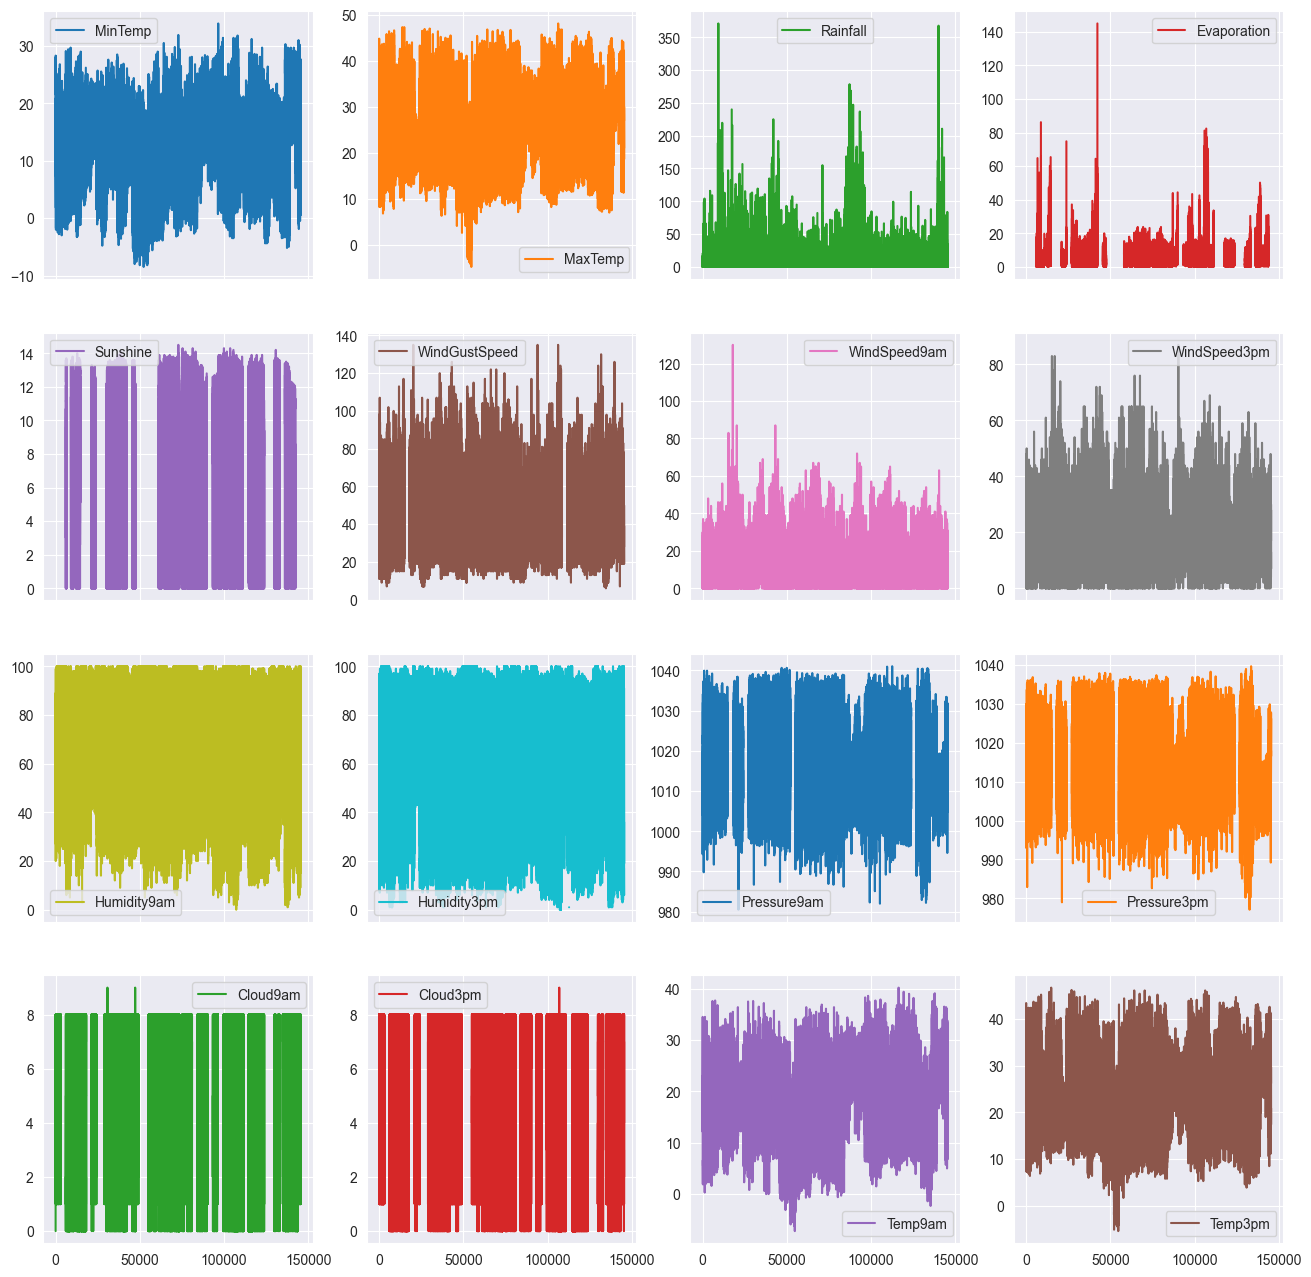

In [5]:
df.describe().T
df.plot(subplots=True, layout=(4,4), figsize=(16, 16))

We see that almost 50 % of values are missing in the fields ”Evaporation”, ”Sunshine”, ”Cloud9am”, ”Cloud3pm”. These are potentially useful fields, however one needs to decide what to do with missing values.

In [12]:
# drop rows with missing "RainTomorrow"
df1 = df.dropna(subset=['RainTomorrow'])

y = df1['RainTomorrow']

df1 = df1.drop([
    'Temp3pm', 'Temp9am', 'Date', 'Location',
    'RainTomorrow', 'WindGustDir', 'WindDir9am'
], axis=1)

X1 = pd.get_dummies(df1)    # mapping of categorical features to a larger set of numerical features with binary values.

X1

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,...,WindDir3pm_S,WindDir3pm_SE,WindDir3pm_SSE,WindDir3pm_SSW,WindDir3pm_SW,WindDir3pm_W,WindDir3pm_WNW,WindDir3pm_WSW,RainToday_No,RainToday_Yes
0,13.4,22.9,0.6,NaN,NaN,44.0,20.0,24.0,71.0,22.0,...,False,False,False,False,False,False,True,False,True,False
1,7.4,25.1,0.0,NaN,NaN,44.0,4.0,22.0,44.0,25.0,...,False,False,False,False,False,False,False,True,True,False
2,12.9,25.7,0.0,NaN,NaN,46.0,19.0,26.0,38.0,30.0,...,False,False,False,False,False,False,False,True,True,False
3,9.2,28.0,0.0,NaN,NaN,24.0,11.0,9.0,45.0,16.0,...,False,False,False,False,False,False,False,False,True,False
4,17.5,32.3,1.0,NaN,NaN,41.0,7.0,20.0,82.0,33.0,...,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145454,3.5,21.8,0.0,NaN,NaN,31.0,15.0,13.0,59.0,27.0,...,False,False,False,False,False,False,False,False,True,False
145455,2.8,23.4,0.0,NaN,NaN,31.0,13.0,11.0,51.0,24.0,...,False,False,False,False,False,False,False,False,True,False
145456,3.6,25.3,0.0,NaN,NaN,22.0,13.0,9.0,56.0,21.0,...,False,False,False,False,False,False,False,False,True,False
145457,5.4,26.9,0.0,NaN,NaN,37.0,9.0,9.0,53.0,24.0,...,False,False,False,False,False,False,True,False,True,False


In this set the outcome (label) variable is also a categorical one. Therefore, it needs to be one hot encoded as well. In principle, one can use `get dummies()` for this as well, which would result in multioutput regression (works out of the box), however in case of a binary output, it’s cheaper to stick to a single output model. Thus, one transforms the outcome into the variable with values 0 and 1 as follows:

In [14]:
# Binarizing the outcome.
from sklearn import preprocessing

lb = preprocessing.LabelBinarizer()
y = lb.fit_transform(y.astype(str)).ravel()
#ravel is opposite of np.newaxis, flattens the array

y

array([0, 0, 0, ..., 0, 0, 0])

We could have dropped from the dataset all the rows
with missing data, but this would severely reduce it. Thus we will fill the missing data
with mean values.

In [19]:
# Imputing missing values
from sklearn.impute import SimpleImputer

imp = SimpleImputer(missing_values=np.nan, strategy='mean')
X = imp.fit_transform(X1)

The keyword argument strategy= defines how the value are filled. Possible values are:
”mean”, ”median”, ”most frequent”, ”constant”.

At this point we are ready to train the model, which is the easiest part of the procedure!

In [20]:
# Train the model.
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

train_X, test_X, train_y, test_y = train_test_split(X, y, test_size = 0.25)

rf = RandomForestClassifier(n_estimators=200, max_depth=10, criterion='gini')

rf.fit(train_X, train_y)

print("Training score:", rf.score(train_X,train_y))
print("Testing score:", rf.score(test_X, test_y))

Training score: 0.8615111961291775
Testing score: 0.8482657740020816


Cross-validation-scores: [0.84603844 0.8416315  0.8432255  0.8464135  0.84602401 0.84630533
 0.84696174 0.84846212 0.84452363 0.84855589]
Mean: 0.8458141662701187
Standard deviation: 0.0020591670563235224
MinTemp 0.020909390950513758
MaxTemp 0.024360118627374295
Rainfall 0.0853960326546068
Evaporation 0.010887576156462884
Sunshine 0.0751379757310175
WindGustSpeed 0.057706999321846676
WindSpeed9am 0.009834011598280047
WindSpeed3pm 0.013222198974248846
Humidity9am 0.05171558095466742
Humidity3pm 0.3276609394806842
Pressure9am 0.04173889087004307
Pressure3pm 0.0580390877674107
Cloud9am 0.02542855877879944
Cloud3pm 0.06935438708579222
WindDir3pm_E 0.0005865277087804332
WindDir3pm_ENE 0.0006583838362331393
WindDir3pm_ESE 0.0006348693505332397
WindDir3pm_N 0.0021719193902357613
WindDir3pm_NE 0.0011158642528510743
WindDir3pm_NNE 0.0012836478815428836
WindDir3pm_NNW 0.0016042015116969925
WindDir3pm_NW 0.0014475010673063117
WindDir3pm_S 0.0010062993584572387
WindDir3pm_SE 0.0007582669552195464


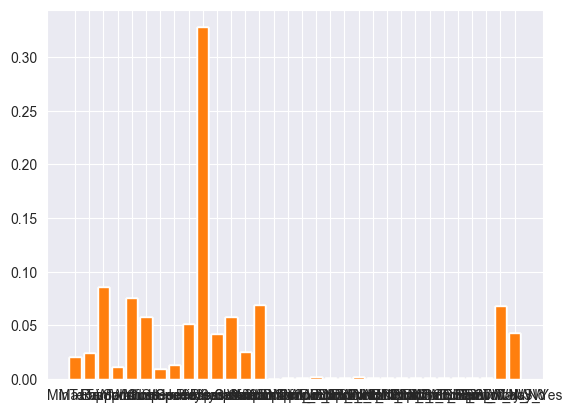

In [21]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(rf, train_X, train_y, cv=10)

print("Cross-validation-scores:", scores )
print("Mean:", scores.mean())
print("Standard deviation:", scores.std())

for i in range(np.shape(X)[1]):
    print(X1.columns[i], rf.feature_importances_[i])
    plt.bar(X1.columns,rf.feature_importances_)

# Tutorial

## Inspect the dataset.

In [9]:
from sklearn import datasets

housing = datasets.fetch_california_housing()

In [12]:
housing.feature_names

['MedInc',
 'HouseAge',
 'AveRooms',
 'AveBedrms',
 'Population',
 'AveOccup',
 'Latitude',
 'Longitude']

In [13]:
housing.data

array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
          37.88      , -122.23      ],
       [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
          37.86      , -122.22      ],
       [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
          37.85      , -122.24      ],
       ...,
       [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
          39.43      , -121.22      ],
       [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
          39.43      , -121.32      ],
       [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
          39.37      , -121.24      ]])

In [14]:
housing.target

array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894])

In [15]:
x = housing.data
y = housing.target

## Split into training and testing data.

In [17]:
from sklearn.model_selection import train_test_split

# Pass the features and targets into this function.
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,     # 20% of data is reserved for testing and evaluation.
    random_state=432,  # Samples are shuffled in a specific order so we can recreate the workflow.
)

## Choosing a model to train the data.

In [18]:
from sklearn.linear_model import LinearRegression

# Initialize the class below your training and testing.
model = LinearRegression()
model.fit(x_train, y_train)     # This trains the model on the training data.

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


The model goes sample by sample and compares each set of features to its target. The model must learn the data rather than memorise it and so we must evaluate it on data it has not seen before.

In [19]:
y_pred = model.predict(x_test)

In [20]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)

print(r2)

0.6080229586580346


Thus, the model understands the relationship between the training and testing data by about 60%. The goal of ML is to improve this R² score. This score is called a **baseline**.

## Optimization
This is the process of making the model smarter.

### 1. Polynomial Features
The first way optimization can be done is by introducing **polynomial features**. This takes the existing 8 features and expands them to generate even more data. The data is expanded by adding additional columns with the squares of data, their products with other columns and so on.

In [21]:
from sklearn.preprocessing import PolynomialFeatures

x = housing.data
y = housing.target

print(x.shape)

poly = PolynomialFeatures()
x = poly.fit_transform(x)       # This expands the features of x by squaring, multiplying columns by each other etc.

print(x.shape)

# Pass the features and targets into this function.
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,     # 20% of data is reserved for testing and evaluation.
    random_state=432,  # Samples are shuffled in a specific order so we can recreate the workflow.
)

# Initialize the class below your training and testing.
model = LinearRegression()
model.fit(x_train, y_train)     # This trains the model on the training data.
y_pred = model.predict(x_test)

r2 = r2_score(y_test, y_pred)

print(r2)

(20640, 8)
(20640, 45)
0.6610240200864264


Simply by increasing number of features, we improved the R² score.

# 2. Other models.

In [22]:
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
)

# Initialize the three models.
LR = LinearRegression()
GBR = GradientBoostingRegressor()
RFR = RandomForestRegressor()

for model in [LR, GBR, RFR]:
    model.fit(x_train, y_train)     # This trains the model on the training data.
    y_pred = model.predict(x_test)

    r2 = r2_score(y_test, y_pred)

    print(model, r2)

0.6610240200864264
0.7918828709337197
0.804580469149449


In [23]:
from sklearn.ensemble import (
    RandomForestRegressor,
    HistGradientBoostingRegressor,
)

# Initialize the three models.
LR = LinearRegression()
GBR = HistGradientBoostingRegressor()       # Uses a faster model.
RFR = RandomForestRegressor(n_jobs=-1)      # Tells the CPU to use all the scores to speed it up.

for model in [LR, GBR, RFR]:
    model.fit(x_train, y_train)     # This trains the model on the training data.
    y_pred = model.predict(x_test)

    r2 = r2_score(y_test, y_pred)

    print(model, r2)

LinearRegression() 0.6610240200864264
HistGradientBoostingRegressor() 0.8370920944452435
RandomForestRegressor(n_jobs=-1) 0.8035988228335482
